# import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")01. Exploración de Datos (EDA)

En esta etapa, nos enfocaremos en entender la naturaleza del dataset de *California Housing*.
**Objetivo:** Obtener un entendimiento de los datos, de la industria, identificar anomalías, rangos, y relaciones clave.

### Instrucciones Generales:
1. **Carga los datos:** Lee el archivo `.csv` proveniente de la carpeta `data/raw/`
2. **Inspección:** Analisis exploratorio de datos, estructura, problemas de calidad: consistencia, sensibilidad, precision y completitud.
3. **Histogramas:** Genera histogramas para cada variable numérica usando `.hist()`.
4. **Visualización Geoespacial:** Crea un gráfico de dispersión (scatter plot) usando `longitude` y `latitude`. 
   - *Tip:* Utiliza el argumento `alpha=0.2` para ver lugares de alta densidad y `c` para colorear acorde a `median_house_value`.
5. **Correlaciones:** Calcula la matriz de correlación (usando `.corr()`) de todas las variables frente a `median_house_value` para encontrar las más prometedoras y graficos de dispercion entre las variables.
6. **Concluciones**: Redactar todos los hallazgos con un lenguaje de negocio y comunicativo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

**DESCRIPCION DEL DATASET**

El dataset contiene información socioeconómica y geográfica de distritos en California, incluyendo variables relacionadas con características habitacionales (habitaciones, población, hogares), nivel de ingresos y ubicación espacial. La estructura de los datos combina variables numéricas continuas con una variable categórica (ocean_proximity), lo que anticipa la necesidad de un tratamiento diferenciado en el proceso de modelado.
Desde una perspectiva de negocio, este dataset permite analizar los determinantes del precio de la vivienda, integrando factores económicos y geográficos en un mismo marco analítico.

In [2]:
train = pd.read_csv("../data/interim/train.csv")
train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY
1,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN
2,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND
3,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND
4,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.3+ MB


**CALIDAD DE DATOS**

El análisis de estructura muestra un dataset mayormente completo, con la excepción de la variable total_bedrooms, que presenta valores faltantes. Este hallazgo es relevante ya que sugiere la necesidad de estrategias de imputación para evitar pérdida de información o sesgos en el modelo.
La consistencia general de los datos es adecuada, aunque la presencia de valores extremos en variables como total_rooms y population indica posibles outliers que podrían distorsionar métricas como la media, tal como se advierte en estadística descriptiva sobre sensibilidad a valores extremos.

In [4]:
train.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16344.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.573125,35.637746,28.577156,2639.402798,538.949094,1425.513929,499.990189,3.870428,206333.518653
std,2.000624,2.133294,12.585738,2185.287466,423.862079,1094.795467,382.865787,1.891936,115314.047529
min,-124.350000,32.550000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.000000,296.000000,787.000000,279.000000,2.562500,119200.000000
50%,-118.510000,34.260000,29.000000,2125.000000,434.000000,1167.000000,408.000000,3.538500,179200.000000
75%,-118.010000,37.720000,37.000000,3154.000000,645.000000,1726.000000,603.000000,4.750000,263925.000000
max,-114.490000,41.950000,52.000000,39320.000000,6210.000000,16305.000000,5358.000000,15.000100,500001.000000


**DISTRIBUCIONES**

Las distribuciones evidencian una marcada asimetría positiva (skewness) en múltiples variables, particularmente en population, total_rooms y median_income. Este comportamiento indica una concentración de valores bajos con colas largas hacia valores altos, lo que sugiere heterogeneidad estructural entre distritos. 
Adicionalmente, la variable objetivo (median_house_value) presenta un truncamiento en su límite superior, lo que sugiere la existencia de un “price cap” en el dataset. Este fenómeno puede limitar la capacidad del modelo para aprender correctamente en rangos altos de precios, introduciendo sesgos sistemáticos en la predicción.

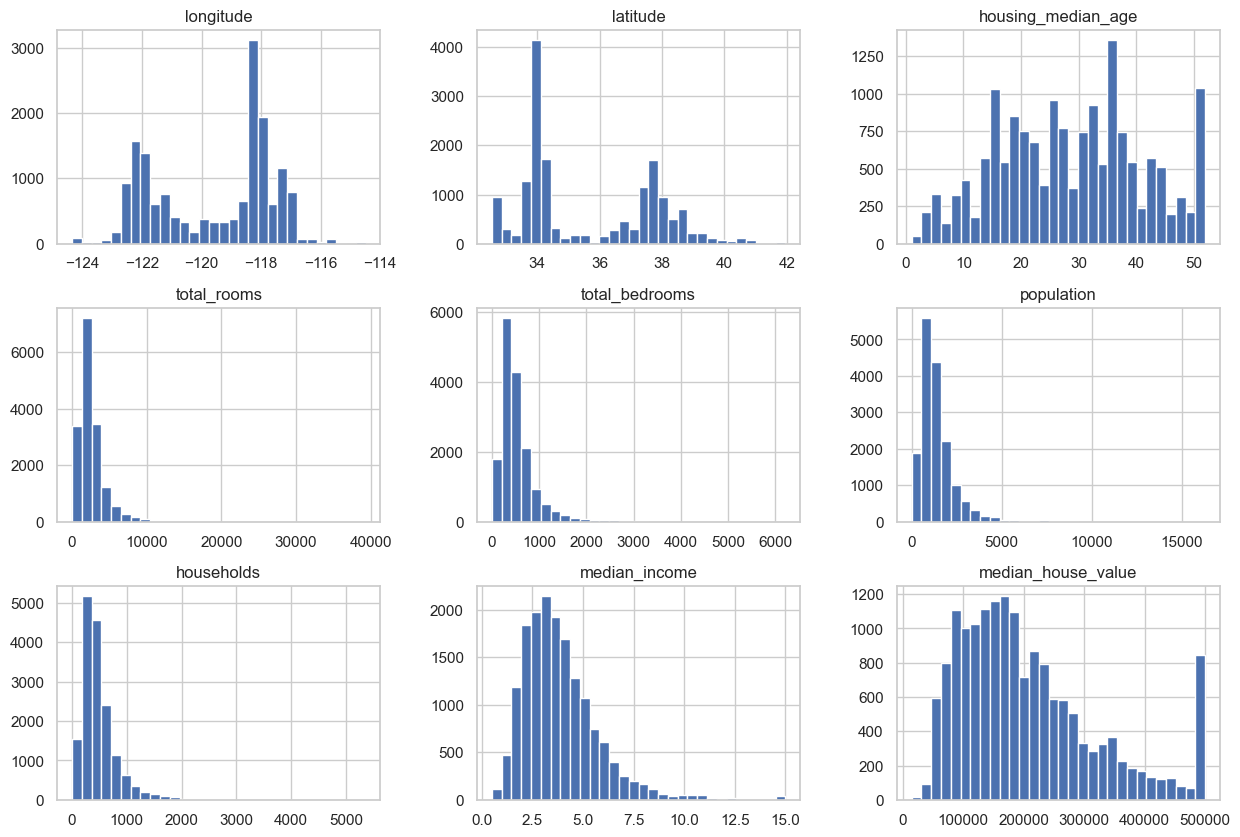

In [5]:
plt.show()

**VARIABLE OBJETIVO**

El precio medio de la vivienda presenta una distribución no normal, con concentración en valores altos y evidencia de censura en el extremo superior. Esto implica que métricas basadas en supuestos de normalidad podrían no ser las más adecuadas, y que modelos capaces de capturar relaciones no lineales podrían tener mejor desempeño.
Desde una perspectiva analítica, este comportamiento sugiere que el problema no es completamente lineal, lo cual influirá directamente en la selección de algoritmos.

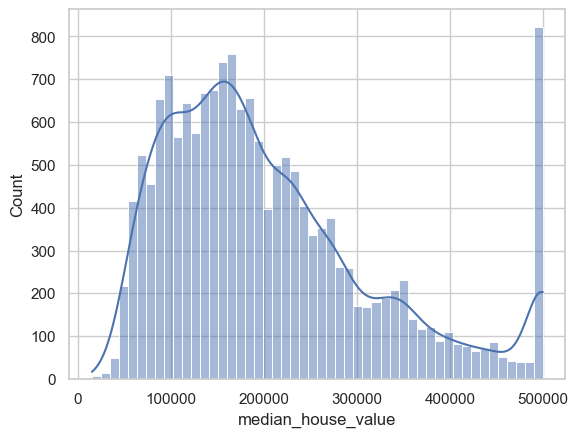

In [6]:
sns.histplot(train["median_house_value"], bins=50, kde=True)
plt.show()

**CORRELACIONES**

El análisis de correlación revela que median_income es la variable con mayor relación lineal respecto al precio de la vivienda, posicionándose como el principal predictor individual. 
Asimismo, se identifican correlaciones entre variables estructurales como número de habitaciones y población, lo que sugiere posibles redundancias o multicolinealidad. Este fenómeno deberá ser considerado en modelos lineales, donde puede afectar la estabilidad de los coeficientes.
Es importante destacar que la correlación no implica causalidad, por lo que estas relaciones deben interpretarse como asociaciones estadísticas y no como efectos directos. 

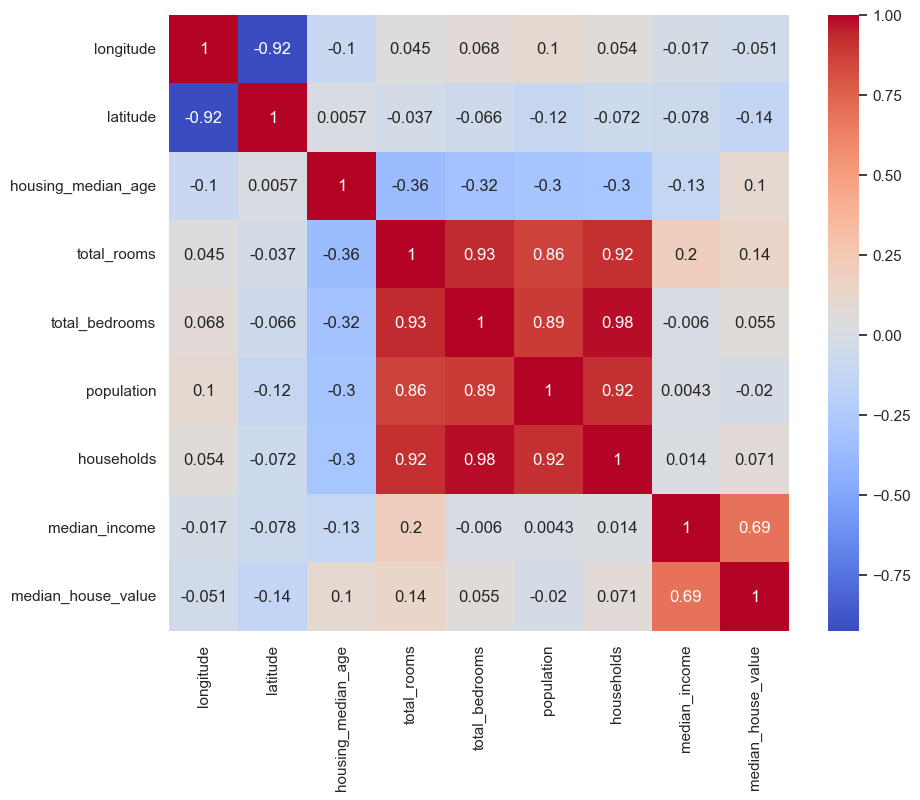

In [7]:
corr = train.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

**RELACION INGRESO – PRECIO**

La relación entre median_income y median_house_value muestra una tendencia positiva clara, confirmando que el ingreso es un determinante clave del valor inmobiliario. Sin embargo, la relación presenta saturación en niveles altos, lo que indica que el efecto marginal del ingreso disminuye en segmentos de mayor poder adquisitivo. 
Este patrón sugiere la presencia de no linealidades, lo que justifica el uso de modelos más flexibles como árboles o ensembles en etapas posteriores.

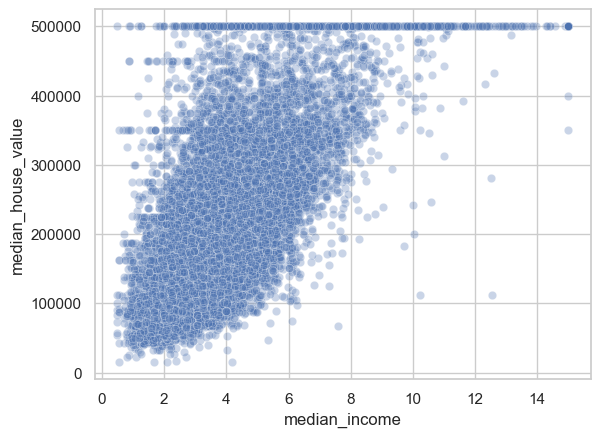

In [8]:
sns.scatterplot(
    data=train,
    x="median_income",
    y="median_house_value",
    alpha=0.3
)
plt.show()

**ANALISIS GEOGRAFICO**

La visualización geoespacial evidencia clusters claros de precios, especialmente en zonas costeras, donde se concentran los valores más altos de vivienda. 
Este patrón confirma que la ubicación es un determinante estructural del precio, y sugiere que variables geográficas no lineales o interacciones espaciales podrían mejorar significativamente el poder predictivo del modelo.
Desde una perspectiva de negocio, esto refleja dinámicas reales del mercado inmobiliario donde la proximidad al mar incrementa el valor percibido.

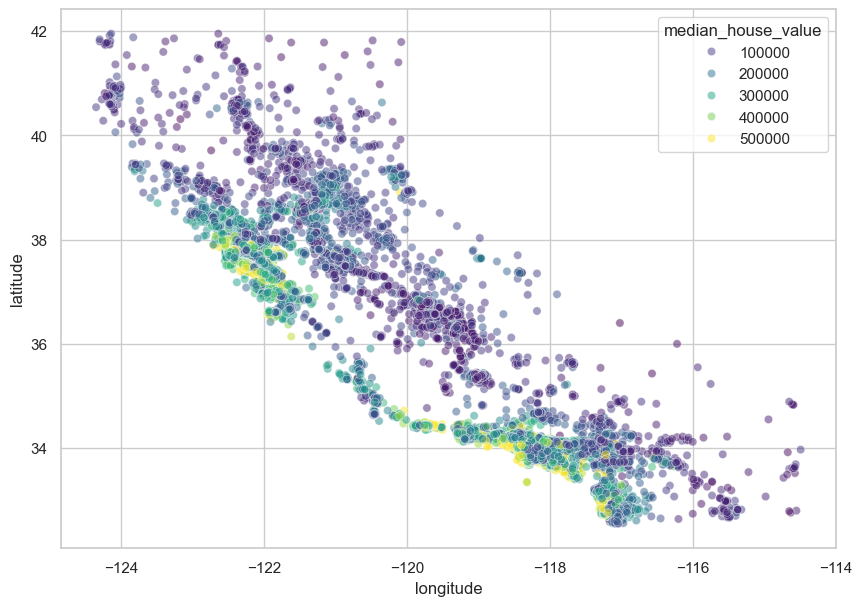

In [9]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=train,
    x="longitude",
    y="latitude",
    hue="median_house_value",
    palette="viridis",
    alpha=0.5
)
plt.show()

**VARIABLE CATEGORICA**

La variable ocean_proximity presenta una distribución desbalanceada, lo que podría influir en el aprendizaje del modelo si no se maneja adecuadamente. Su correcta codificación será clave para capturar el efecto de localización sin introducir sesgos.
Además, esta variable representa una abstracción relevante de la ubicación, lo que la convierte en un predictor potencialmente potente.

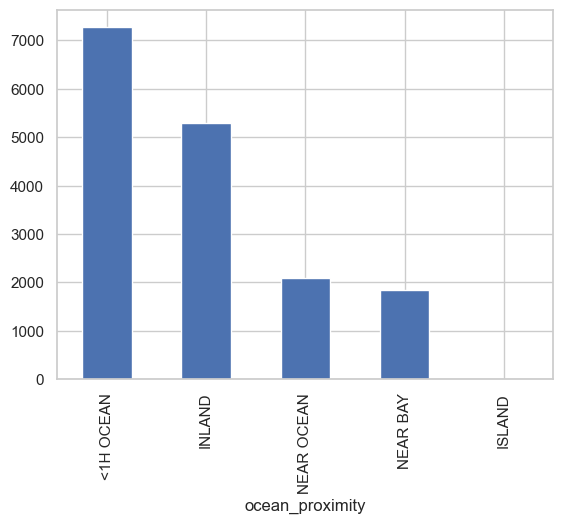

In [10]:
train["ocean_proximity"].value_counts().plot(kind="bar")
plt.show()

**CONCLUSION**

El análisis exploratorio confirma que el precio de la vivienda está principalmente determinado por dos dimensiones clave: el nivel de ingreso y la localización geográfica. La presencia de asimetrías, valores extremos y relaciones no lineales indica que el problema presenta una complejidad estructural que no puede ser capturada adecuadamente por modelos lineales simples.
En este contexto, la ingeniería de variables será crítica para transformar información bruta en señales más representativas, mientras que la selección de modelos deberá priorizar enfoques capaces de capturar interacciones y no linealidades. Este diagnóstico se alinea con el principio de que una correcta fase descriptiva es la base para construir modelos predictivos robustos. 